# Bank Customer Churn – Classification & Explainable AI (XAI)

**Course:** 2400-DS2ML2 – Machine Learning 2  
**Authors:** Ronald Mjonono (473522) · Linxiao Mu (474569)

### Pipeline Overview
1. Exploratory Data Analysis (EDA)
2. Preprocessing and train–test split
3. Decision Tree classifier
4. Random Forest
5. Gradient Boosting
6. Neural Network (MLP)
7. Model evaluation & comparison
8. Baseline feature importance
9. XAI – SHAP global analysis
10. XAI – SHAP local explanations
11. XAI – SHAP dependence plots
12. XAI – SHAP cross-model comparison
13. XAI – LIME local explanations
14. XAI – Business segmentation
15. Conclusions

## 0. Imports & Setup

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

import shap
import lime
import lime.lime_tabular

shap.initjs()
pd.set_option("display.max_columns", None)
sns.set_theme()

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Data Loading and Initial Inspection

In [15]:
df = pd.read_csv("../data/Churn_Modelling.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [17]:
df.isna().sum().sort_values(ascending=False)

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [18]:
id_like_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
print("Dropping:", id_like_cols)
df = df.drop(columns=id_like_cols)
df.head(3)

Dropping: ['RowNumber', 'CustomerId', 'Surname']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


## 2. Exploratory Data Analysis (EDA)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


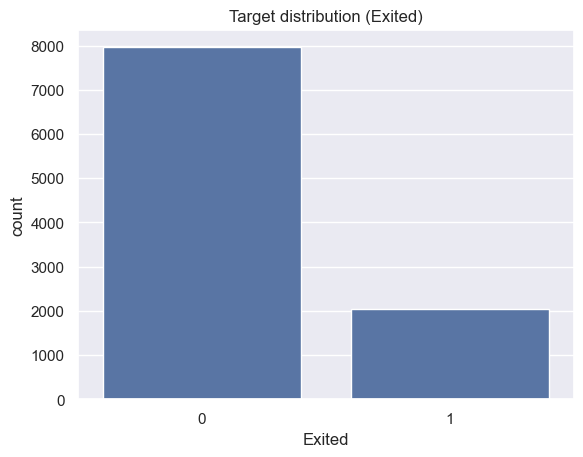

In [19]:
target_col = "Exited"
print(df[target_col].value_counts(normalize=True).rename("proportion"))

sns.countplot(x=target_col, data=df)
plt.title("Target distribution (Exited)")
plt.show()


In [20]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

if target_col in numeric_features:
    numeric_features.remove(target_col)
if target_col in categorical_features:
    categorical_features.remove(target_col)

print("Numeric features   :", numeric_features)
print("Categorical features:", categorical_features)

Numeric features   : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical features: ['Geography', 'Gender']


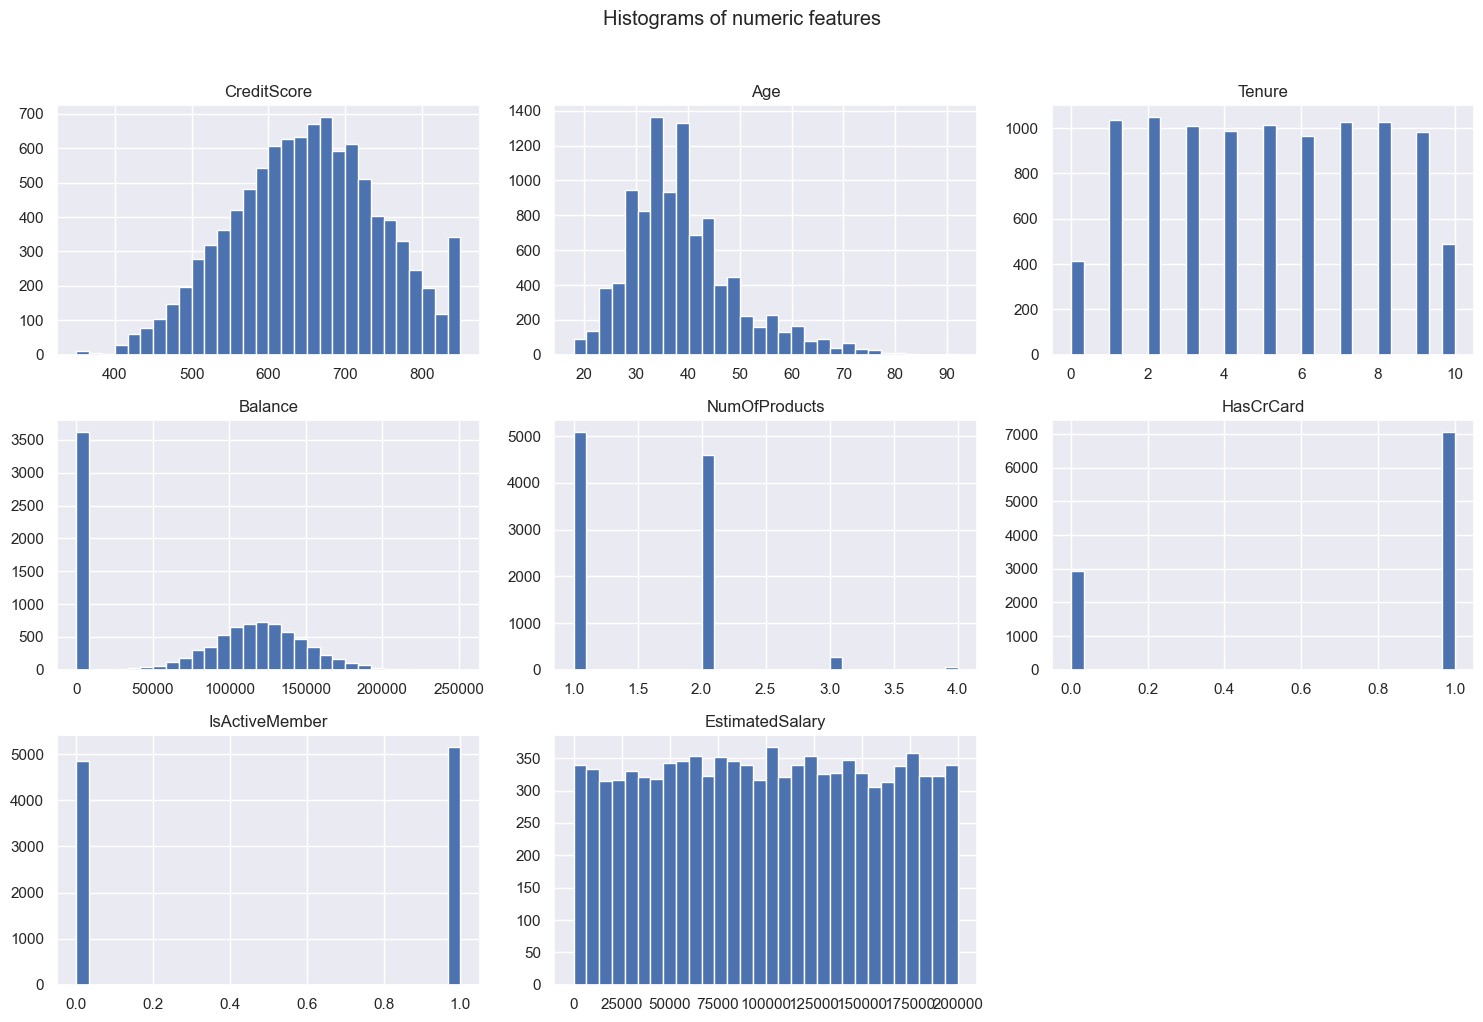

In [21]:
df[numeric_features].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of numeric features", y=1.02)
plt.tight_layout()
plt.show()

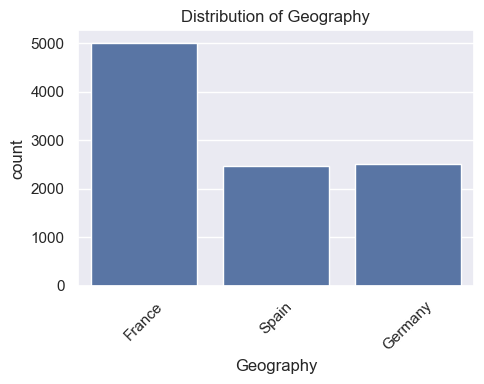

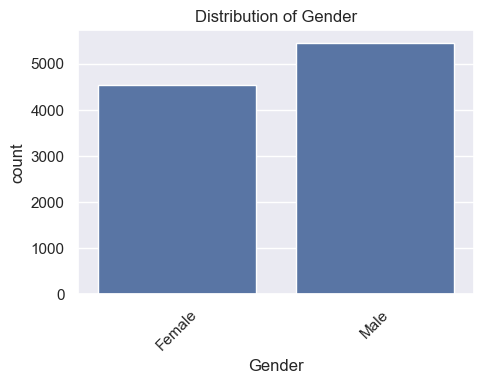

In [22]:
for col in categorical_features:
    plt.figure(figsize=(5, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

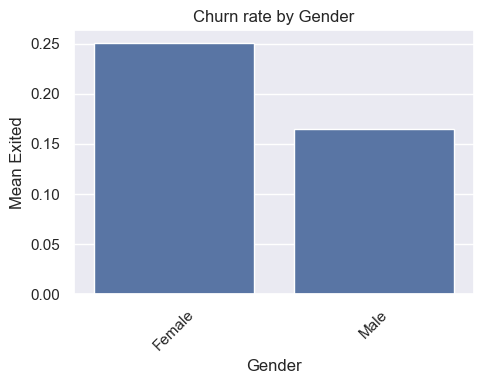

In [23]:
if col in categorical_features:
    plt.figure(figsize=(5, 4))
    churn_rate = df.groupby(col)[target_col].mean()

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )

    plt.title(f"Churn rate by {col}")
    plt.ylabel("Mean Exited")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

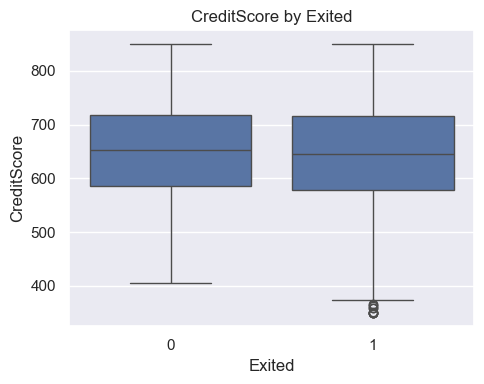

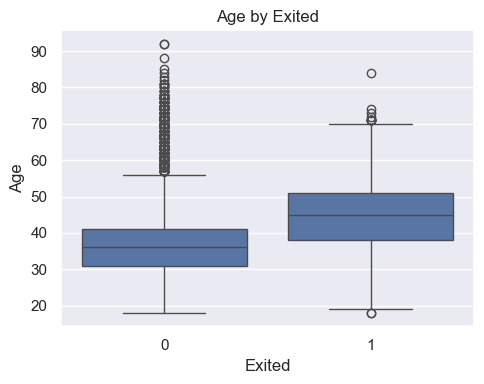

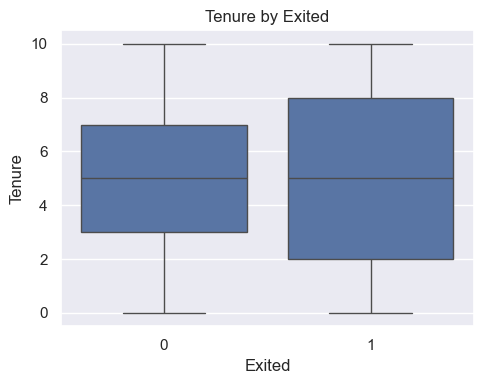

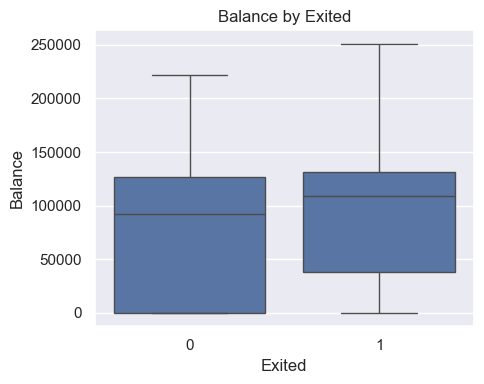

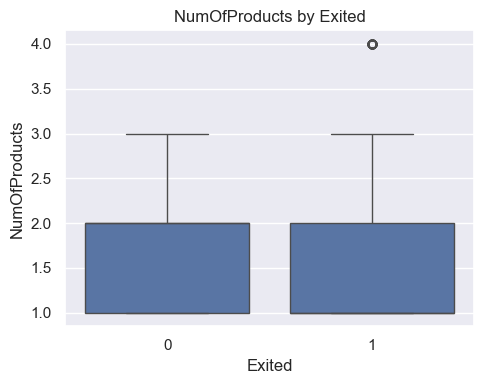

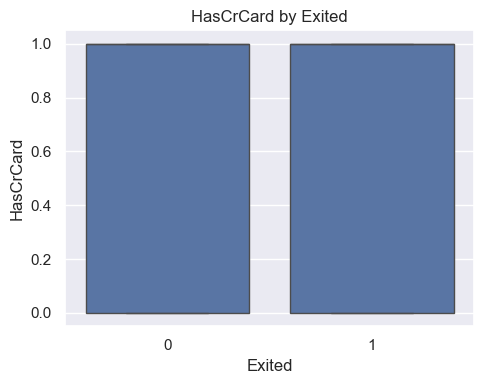

In [24]:
for col in numeric_features[:6]:
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by Exited")
    plt.tight_layout()
    plt.show()

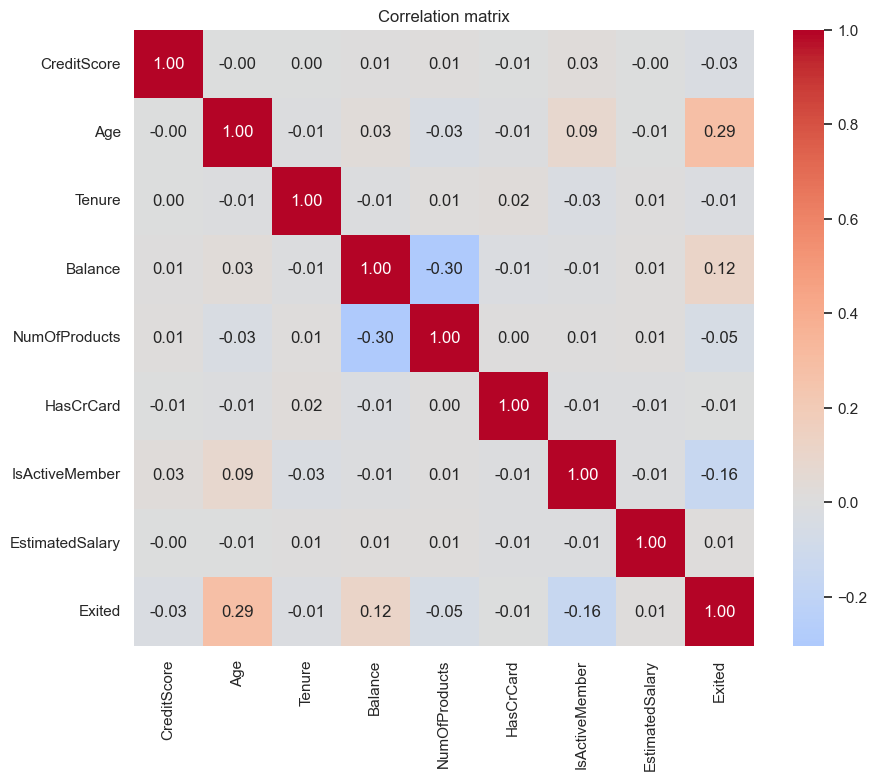

In [25]:
corr = df[numeric_features + [target_col]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

## 3. Train–Test Split and Preprocessing

In [26]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tree_preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

nn_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (7000, 10)
Test shape : (3000, 10)


## 4. Evaluation Helper Function

In [27]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan

    print(f"=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}  ROC AUC: {auc:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, zero_division=0))

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "roc_auc": auc}

## 5. Decision Tree Classifier

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dtree = Pipeline([
    ("preprocess", tree_preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    "clf__max_depth"        : [3, 5, 8, None],
    "clf__min_samples_split": [2, 10, 20],
    "clf__min_samples_leaf" : [1, 5, 10],
    "clf__criterion"        : ["gini", "entropy"]
}

print("Training Decision Tree...")
grid_tree = GridSearchCV(dtree, param_grid_tree, cv=cv, scoring="roc_auc", n_jobs=1)
grid_tree.fit(X_train, y_train)
print("Best params:", grid_tree.best_params_)

best_tree    = grid_tree.best_estimator_
y_pred_tree  = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]
tree_results = evaluate_model(y_test, y_pred_tree, y_proba_tree, "Decision Tree")

Training Decision Tree...
Best params: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 20}
=== Decision Tree ===
Accuracy: 0.8590  Precision: 0.7956  Recall: 0.4141  F1: 0.5447  ROC AUC: 0.8524
Confusion matrix:
 [[2324   65]
 [ 358  253]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2389
           1       0.80      0.41      0.54       611

    accuracy                           0.86      3000
   macro avg       0.83      0.69      0.73      3000
weighted avg       0.85      0.86      0.84      3000



## 6. Random Forest

In [29]:
rf = Pipeline([
    ("preprocess", tree_preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "clf__n_estimators"     : [100, 200],
    "clf__max_depth"        : [None, 6, 10],
    "clf__max_features"     : ["sqrt", "log2"],
    "clf__min_samples_split": [2, 10]
}

print("Training Random Forest...")
grid_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=1)
grid_rf.fit(X_train, y_train)
print("Best params:", grid_rf.best_params_)

best_rf    = grid_rf.best_estimator_
y_pred_rf  = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
rf_results = evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")

Training Random Forest...
Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
=== Random Forest ===
Accuracy: 0.8723  Precision: 0.8373  Recall: 0.4632  F1: 0.5964  ROC AUC: 0.8789
Confusion matrix:
 [[2334   55]
 [ 328  283]]
              precision    recall  f1-score   support

           0       0.88      0.98      0.92      2389
           1       0.84      0.46      0.60       611

    accuracy                           0.87      3000
   macro avg       0.86      0.72      0.76      3000
weighted avg       0.87      0.87      0.86      3000



## 7. Gradient Boosting

In [30]:
gb = Pipeline([
    ("preprocess", tree_preprocessor),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "clf__n_estimators" : [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth"    : [2, 3],
    "clf__subsample"    : [0.8, 1.0]
}

print("Training Gradient Boosting...")
grid_gb = GridSearchCV(gb, param_grid_gb, cv=cv, scoring="roc_auc", n_jobs=1)
grid_gb.fit(X_train, y_train)
print("Best params:", grid_gb.best_params_)

best_gb    = grid_gb.best_estimator_
y_pred_gb  = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]
gb_results = evaluate_model(y_test, y_pred_gb, y_proba_gb, "Gradient Boosting")

Training Gradient Boosting...
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
=== Gradient Boosting ===
Accuracy: 0.8723  Precision: 0.8000  Recall: 0.4975  F1: 0.6135  ROC AUC: 0.8822
Confusion matrix:
 [[2313   76]
 [ 307  304]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2389
           1       0.80      0.50      0.61       611

    accuracy                           0.87      3000
   macro avg       0.84      0.73      0.77      3000
weighted avg       0.87      0.87      0.86      3000



## 8. Neural Network (MLP)

In [31]:
mlp = Pipeline([
    ("preprocess", nn_preprocessor),
    ("clf", MLPClassifier(max_iter=200, random_state=42))
])

param_grid_mlp = {
    "clf__hidden_layer_sizes": [(32,), (64, 32)],
    "clf__alpha"             : [0.0001, 0.001],
    "clf__learning_rate_init": [0.001, 0.01]
}

print("Training MLP...")
grid_mlp = GridSearchCV(mlp, param_grid_mlp, cv=cv, scoring="roc_auc", n_jobs=1)
grid_mlp.fit(X_train, y_train)
print("Best params:", grid_mlp.best_params_)

best_mlp    = grid_mlp.best_estimator_
y_pred_mlp  = best_mlp.predict(X_test)
y_proba_mlp = best_mlp.predict_proba(X_test)[:, 1]
mlp_results = evaluate_model(y_test, y_pred_mlp, y_proba_mlp, "Neural Network (MLP)")

Training MLP...
Best params: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (32,), 'clf__learning_rate_init': 0.001}
=== Neural Network (MLP) ===
Accuracy: 0.8680  Precision: 0.7628  Recall: 0.5106  F1: 0.6118  ROC AUC: 0.8734
Confusion matrix:
 [[2292   97]
 [ 299  312]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      2389
           1       0.76      0.51      0.61       611

    accuracy                           0.87      3000
   macro avg       0.82      0.74      0.77      3000
weighted avg       0.86      0.87      0.86      3000



## 9. Model Comparison

In [32]:
results_df = pd.DataFrame([tree_results, rf_results, gb_results, mlp_results])
results_df.set_index("model", inplace=True)
print(results_df.round(4))


                      accuracy  precision  recall      f1  roc_auc
model                                                             
Decision Tree           0.8590     0.7956  0.4141  0.5447   0.8524
Random Forest           0.8723     0.8373  0.4632  0.5964   0.8789
Gradient Boosting       0.8723     0.8000  0.4975  0.6135   0.8822
Neural Network (MLP)    0.8680     0.7628  0.5106  0.6118   0.8734


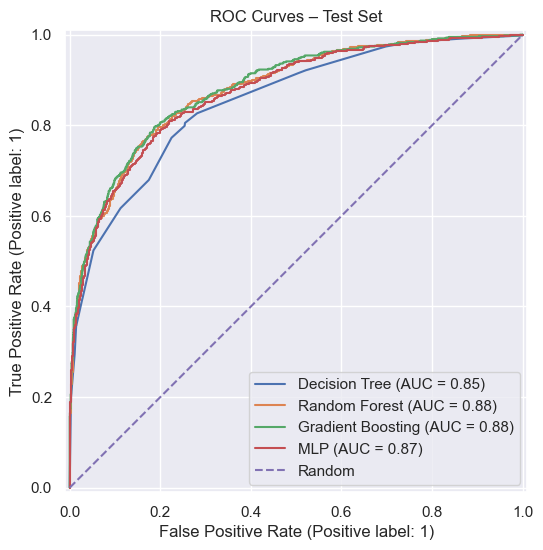

In [33]:
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_tree, name="Decision Tree", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_proba_rf,   name="Random Forest", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_proba_gb,   name="Gradient Boosting", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, y_proba_mlp,  name="MLP", ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curves – Test Set")
plt.legend()
plt.show()

## 10. Baseline Feature Importance (Gini)

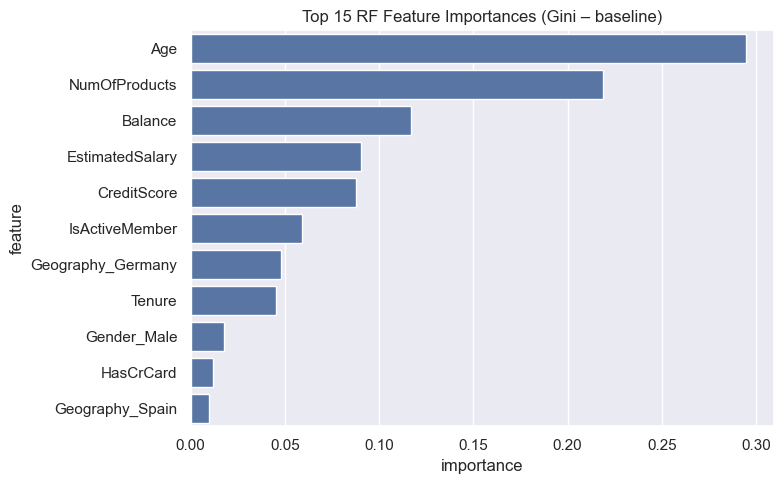

In [34]:
preprocessor    = best_rf.named_steps["preprocess"]
rf_clf          = best_rf.named_steps["clf"]
cat_enc         = preprocessor.named_transformers_["cat"]
cat_names_out   = list(cat_enc.get_feature_names_out(categorical_features))
all_feat_names  = list(numeric_features) + cat_names_out

fi_df = pd.DataFrame({
    "feature"   : all_feat_names,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=fi_df.head(15), orient="h")
plt.title("Top 15 RF Feature Importances (Gini – baseline)")
plt.tight_layout()
plt.show()

## 11. XAI – SHAP Setup

In [35]:
X_train_t  = preprocessor.transform(X_train)
X_test_t   = preprocessor.transform(X_test)
X_train_df = pd.DataFrame(X_train_t, columns=all_feat_names)
X_test_df  = pd.DataFrame(X_test_t,  columns=all_feat_names)

print("Computing SHAP values (RF)...")
explainer_rf   = shap.TreeExplainer(rf_clf)
shap_values_rf = explainer_rf.shap_values(X_test_df)

if isinstance(shap_values_rf, list):
    sv_rf = shap_values_rf[1]
elif hasattr(shap_values_rf, 'shape') and len(shap_values_rf.shape) == 3:
    sv_rf = shap_values_rf[:, :, 1]
else:
    sv_rf = shap_values_rf

base_val = explainer_rf.expected_value[1] if hasattr(explainer_rf.expected_value, '__len__') else explainer_rf.expected_value

print(f"SHAP value matrix shape: {sv_rf.shape}")

Computing SHAP values (RF)...
SHAP value matrix shape: (3000, 11)


## 12. XAI – SHAP Global Analysis

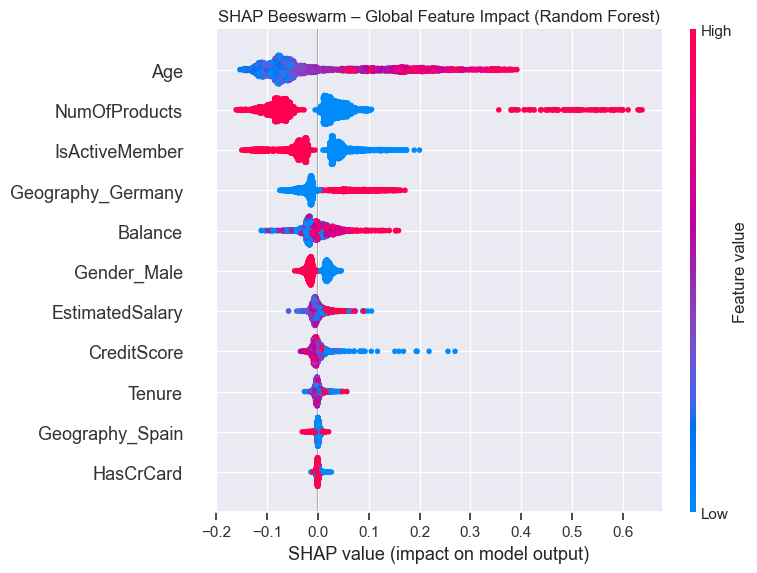

In [36]:
plt.figure()
shap.summary_plot(sv_rf, X_test_df, feature_names=all_feat_names, show=False, max_display=15)
plt.title("SHAP Beeswarm – Global Feature Impact (Random Forest)")
plt.tight_layout()
plt.show()

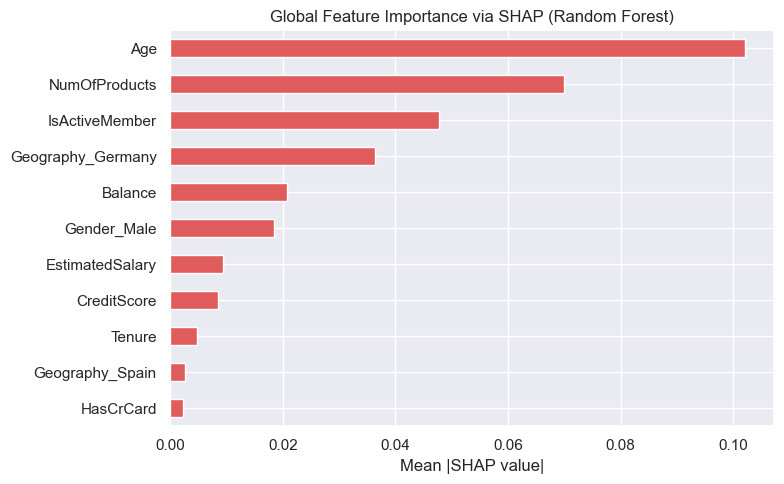


Top 10 features by mean |SHAP|:
Age                  0.1021
NumOfProducts        0.0700
IsActiveMember       0.0478
Geography_Germany    0.0364
Balance              0.0208
Gender_Male          0.0184
EstimatedSalary      0.0094
CreditScore          0.0084
Tenure               0.0047
Geography_Spain      0.0027


In [37]:
mean_abs_shap = pd.Series(np.abs(sv_rf).mean(axis=0), index=all_feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
mean_abs_shap.head(15).sort_values().plot(kind="barh", color="#e05c5c", ax=ax)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Global Feature Importance via SHAP (Random Forest)")
plt.tight_layout()
plt.show()

print("\nTop 10 features by mean |SHAP|:")
print(mean_abs_shap.head(10).round(4).to_string())

## 13. XAI – SHAP Local Explanations (Waterfall)

Customer #17
  Predicted churn probability : 81.76%
  Actual label (Exited)        : 1


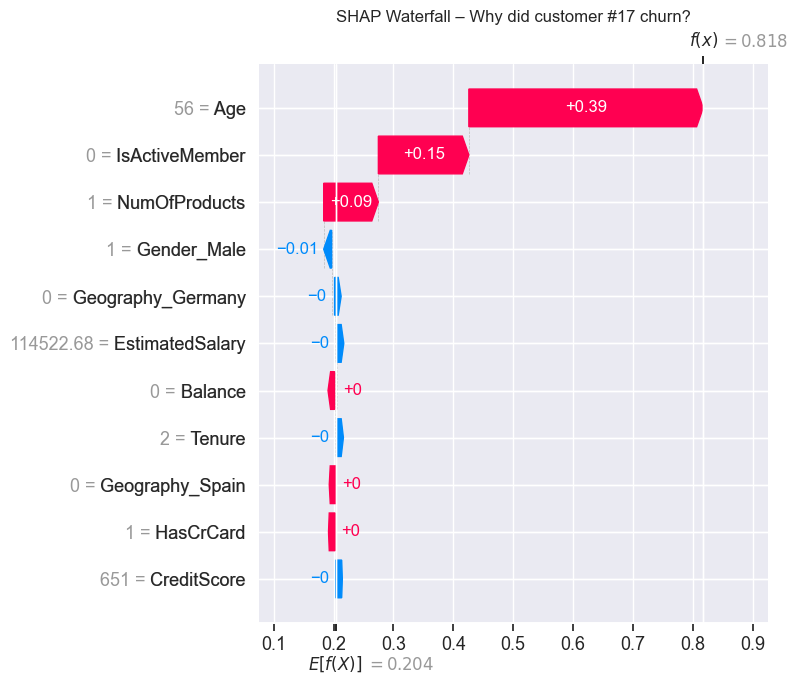

In [38]:
rf_proba_test = best_rf.predict_proba(X_test)[:, 1]
churn_idx     = np.where((rf_proba_test > 0.80) & (y_test.values == 1))[0]
if len(churn_idx) == 0:
    churn_idx = np.where(rf_proba_test > 0.70)[0]
customer_idx  = churn_idx[0]

print(f"Customer #{customer_idx}")
print(f"  Predicted churn probability : {rf_proba_test[customer_idx]:.2%}")
print(f"  Actual label (Exited)        : {y_test.values[customer_idx]}")

exp_churn = shap.Explanation(
    values        = sv_rf[customer_idx],
    base_values   = base_val,
    data          = X_test_df.iloc[customer_idx].values,
    feature_names = all_feat_names
)

plt.figure()
shap.plots.waterfall(exp_churn, max_display=12, show=False)
plt.title(f"SHAP Waterfall – Why did customer #{customer_idx} churn?")
plt.tight_layout()
plt.show()

Customer #0
  Predicted churn probability : 1.46%
  Actual label (Exited)        : 0


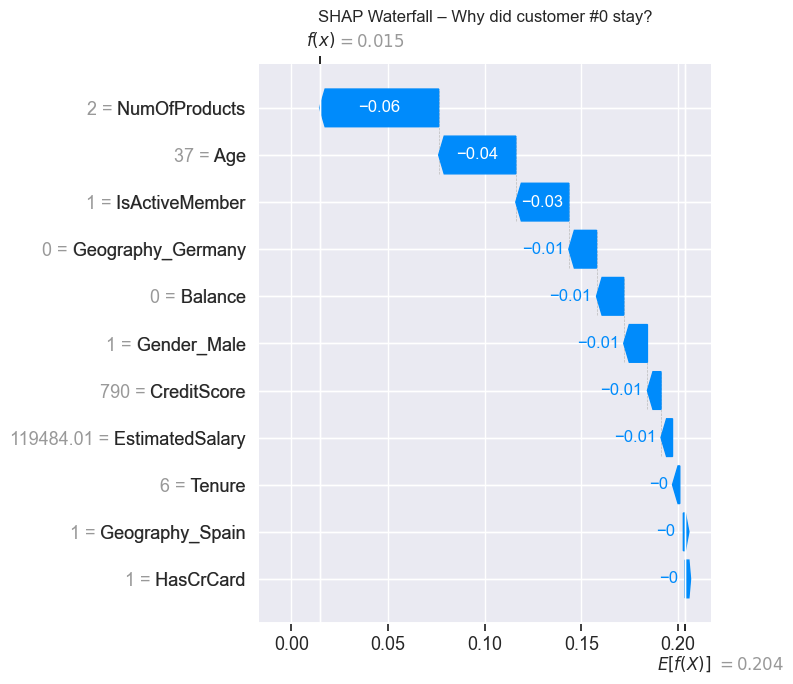

In [39]:
stay_idx      = np.where((rf_proba_test < 0.20) & (y_test.values == 0))[0]
if len(stay_idx) == 0:
    stay_idx = np.where(rf_proba_test < 0.30)[0]
customer_idx2 = stay_idx[0]

print(f"Customer #{customer_idx2}")
print(f"  Predicted churn probability : {rf_proba_test[customer_idx2]:.2%}")
print(f"  Actual label (Exited)        : {y_test.values[customer_idx2]}")

exp_stay = shap.Explanation(
    values        = sv_rf[customer_idx2],
    base_values   = base_val,
    data          = X_test_df.iloc[customer_idx2].values,
    feature_names = all_feat_names
)

plt.figure()
shap.plots.waterfall(exp_stay, max_display=12, show=False)
plt.title(f"SHAP Waterfall – Why did customer #{customer_idx2} stay?")
plt.tight_layout()
plt.show()

## 14. XAI – SHAP Dependence Plots

<Figure size 640x480 with 0 Axes>

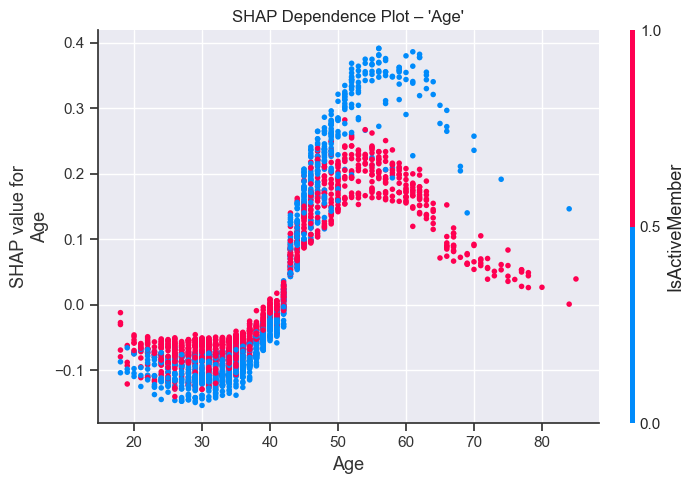

<Figure size 640x480 with 0 Axes>

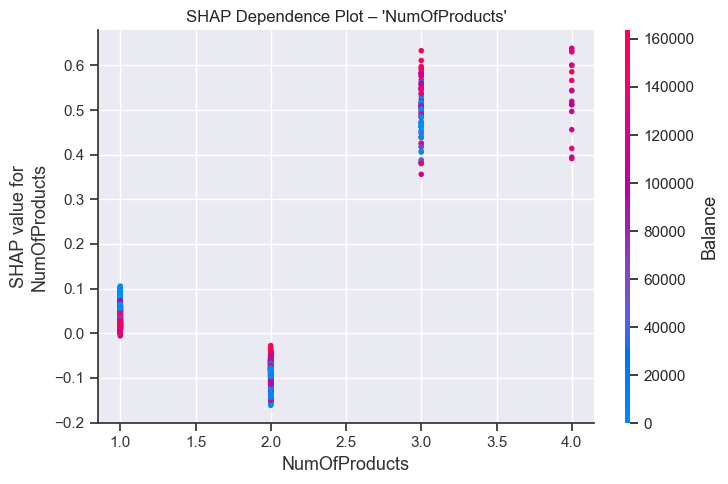

In [40]:
for feat in [mean_abs_shap.index[0], mean_abs_shap.index[1]]:
    plt.figure()
    shap.dependence_plot(feat, sv_rf, X_test_df, feature_names=all_feat_names, show=False)
    plt.title(f"SHAP Dependence Plot – '{feat}'")
    plt.tight_layout()
    plt.show()

## 15. XAI – SHAP on Gradient Boosting (Cross-Model Comparison)

Computing SHAP values (GBM)...


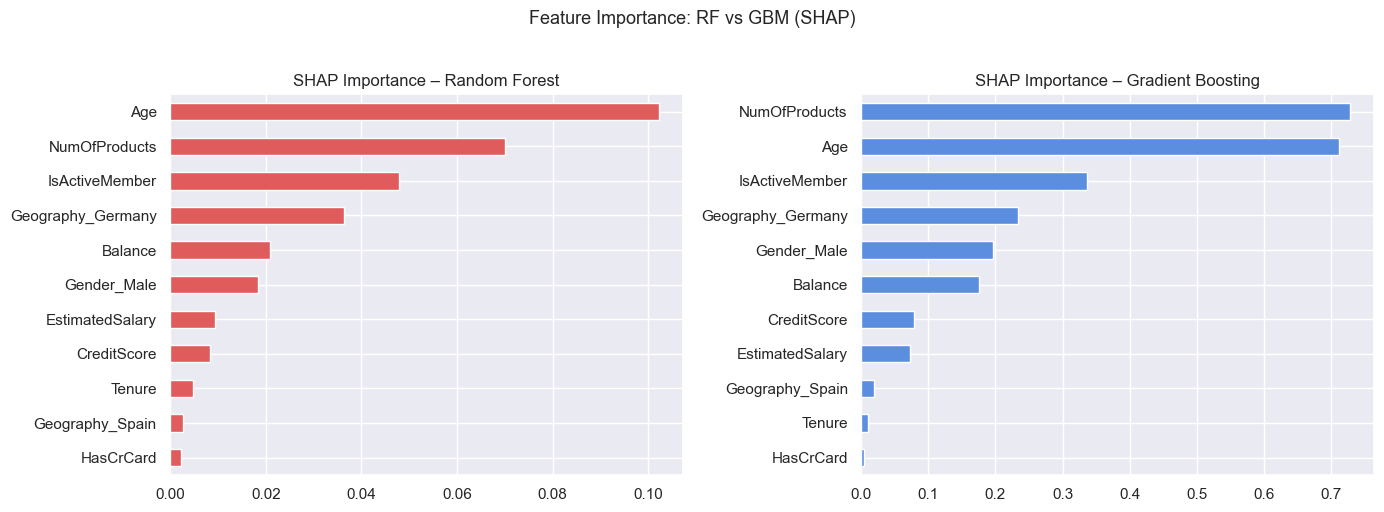


Top 5 – Random Forest  : ['Age', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Balance']
Top 5 – Gradient Boosting: ['NumOfProducts', 'Age', 'IsActiveMember', 'Geography_Germany', 'Gender_Male']


In [41]:
print("Computing SHAP values (GBM)...")
gb_clf       = best_gb.named_steps["clf"]
X_test_df_gb = pd.DataFrame(best_gb.named_steps["preprocess"].transform(X_test), columns=all_feat_names)
explainer_gb = shap.TreeExplainer(gb_clf)
shap_values_gb = explainer_gb.shap_values(X_test_df_gb)

if isinstance(shap_values_gb, list):
    sv_gb = shap_values_gb[1]
elif hasattr(shap_values_gb, 'shape') and len(shap_values_gb.shape) == 3:
    sv_gb = shap_values_gb[:, :, 1]
else:
    sv_gb = shap_values_gb

mean_abs_shap_gb = pd.Series(np.abs(sv_gb).mean(axis=0), index=all_feat_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=axes[0], color="#e05c5c")
axes[0].set_title("SHAP Importance – Random Forest")
mean_abs_shap_gb.head(12).sort_values().plot(kind="barh", ax=axes[1], color="#5c8ee0")
axes[1].set_title("SHAP Importance – Gradient Boosting")
plt.suptitle("Feature Importance: RF vs GBM (SHAP)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 5 – Random Forest  :", mean_abs_shap.head(5).index.tolist())
print("Top 5 – Gradient Boosting:", mean_abs_shap_gb.head(5).index.tolist())

## 16. XAI – LIME Local Explanations (Neural Network)

Computing LIME explanation (MLP)...


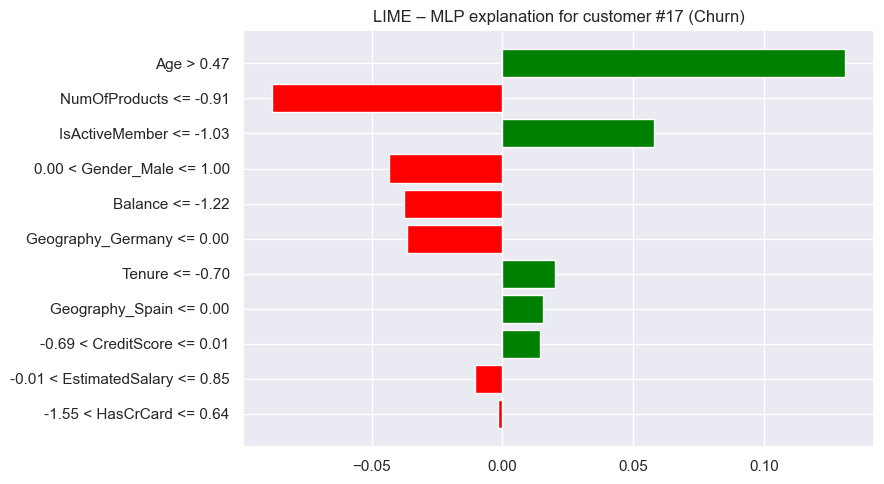

In [42]:
print("Computing LIME explanation (MLP)...")
mlp_clf       = best_mlp.named_steps["clf"]
X_train_t_mlp = best_mlp.named_steps["preprocess"].transform(X_train)
X_test_t_mlp  = best_mlp.named_steps["preprocess"].transform(X_test)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train_t_mlp,
    feature_names         = all_feat_names,
    class_names           = ["Stayed", "Churned"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

lime_exp = lime_explainer.explain_instance(
    data_row   = X_test_t_mlp[customer_idx],
    predict_fn = mlp_clf.predict_proba,
    num_features = 12,
    num_samples  = 1000,
    labels       = (1,)
)

fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
plt.title(f"LIME – MLP explanation for customer #{customer_idx} (Churn)")
plt.tight_layout()
plt.show()

## 17. XAI – Business Segmentation

In [43]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
segment_df   = X_test_reset.copy()
segment_df["churn_proba"]  = rf_proba_test
segment_df["actual_churn"] = y_test_reset.values
segment_df["risk_group"]   = pd.cut(
    segment_df["churn_proba"],
    bins   = [0, 0.33, 0.66, 1.0],
    labels = ["Low risk", "Medium risk", "High risk"]
)
segment_df["row_idx"] = range(len(segment_df))

print("=== Segment distribution ===")
print(segment_df["risk_group"].value_counts())
print("\n=== Mean features by risk group ===")
print(segment_df.groupby("risk_group")[numeric_features].mean().round(2).T.to_string())

=== Segment distribution ===
risk_group
Low risk       2428
Medium risk     359
High risk       213
Name: count, dtype: int64

=== Mean features by risk group ===
risk_group        Low risk  Medium risk  High risk
CreditScore         651.64       645.35     645.51
Age                  36.54        46.91      50.04
Tenure                5.06         4.69       5.07
Balance           72284.75     95897.04   97292.18
NumOfProducts         1.54         1.22       1.80
HasCrCard             0.70         0.72       0.69
IsActiveMember        0.57         0.35       0.16
EstimatedSalary  101190.93    104673.06  100323.88


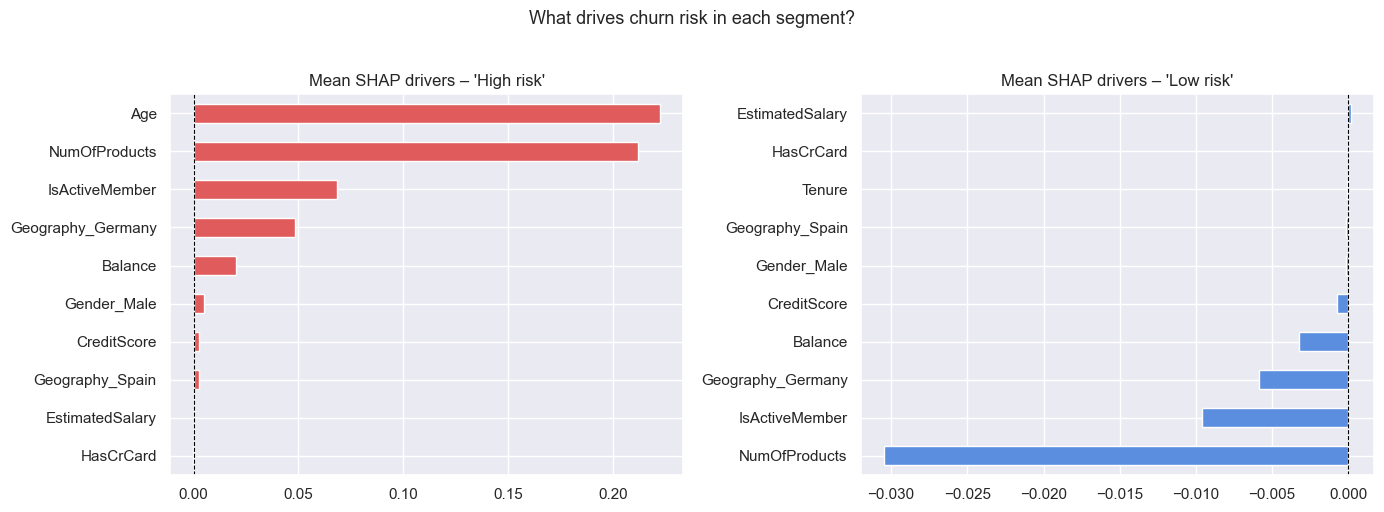

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, group_label, color in zip(axes, ["High risk", "Low risk"], ["#e05c5c", "#5c8ee0"]):
    idx = segment_df[segment_df["risk_group"] == group_label]["row_idx"].values
    pd.Series(sv_rf[idx].mean(axis=0), index=all_feat_names)\
      .sort_values(ascending=False).head(10).sort_values()\
      .plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Mean SHAP drivers – '{group_label}'")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.suptitle("What drives churn risk in each segment?", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 18. Conclusions

### Model Performance
Gradient Boosting achieved the best ROC AUC (0.882) and F1 (0.614). Random Forest was a close second and was used as the primary model for SHAP analysis due to its compatibility with TreeExplainer. Accuracy alone is misleading given the 80/20 class imbalance — ROC AUC and F1 were the primary metrics.

### XAI Findings
SHAP analysis consistently identified three dominant churn drivers across both Random Forest and Gradient Boosting:
- **Age** — churn risk rises sharply after 40 and peaks around 50–60, revealing a clear non-linear threshold
- **NumOfProducts** — customers with 3–4 products churn more, contradicting the assumption that more products means more loyalty
- **IsActiveMember** — inactive members are significantly more likely to churn and represent the most actionable target

LIME applied to the Neural Network confirmed these findings at the individual level, giving us confidence the results are robust across models and methods.

### Business Recommendations
The bank should prioritise retention outreach for inactive customers aged 40–60, particularly in Germany. Reactivation campaigns and a review of the product bundling strategy are the most actionable next steps.

### Limitations
- Dataset is from Kaggle for educational use — may not reflect real bank behaviour
- Correlations are identified but not causal mechanisms
- Class imbalance was not addressed with resampling
- LIME is a local approximation and may vary across random seeds